# Experiment No. 6

## Title
**To implement Two-Dimensional (2D) Transformations on a geometric object**

## Objective
To apply basic 2D transformations such as translation, scaling, rotation, shearing, and reflection on a 2D object and display the results using subplots.

## Theory
Two-dimensional transformations are used in computer graphics to modify the position, size, orientation, and shape of objects. These transformations are commonly represented using matrix operations.

For a point $(x, y)$, transformations can be written in matrix form.

### 1. Translation
Translation shifts an object by $(t_x, t_y)$:

$$
x' = x + t_x,\qquad y' = y + t_y
$$

Matrix form (using homogeneous coordinates):

$$
\begin{bmatrix}
x' \\
y' \\
1
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 & t_x \\
0 & 1 & t_y \\
0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
x \\
y \\
1
\end{bmatrix}
$$

---

### 2. Scaling
Scaling changes the size of an object by factors $(s_x, s_y)$:

$$
x' = x \cdot s_x,\qquad y' = y \cdot s_y
$$

Matrix form:

$$
\begin{bmatrix}
x' \\
y'
\end{bmatrix}
=
\begin{bmatrix}
s_x & 0 \\
0 & s_y
\end{bmatrix}
\begin{bmatrix}
x \\
y
\end{bmatrix}
$$

---

### 3. Rotation
Rotation rotates an object by an angle $\theta$ about the origin:

$$
x' = x\cos\theta - y\sin\theta
$$

$$
y' = x\sin\theta + y\cos\theta
$$

Matrix form:

$$
\begin{bmatrix}
x' \\
y'
\end{bmatrix}
=
\begin{bmatrix}
\cos\theta & -\sin\theta \\
\sin\theta & \cos\theta
\end{bmatrix}
\begin{bmatrix}
x \\
y
\end{bmatrix}
$$

---

### 4. Shearing
Shearing distorts the shape of an object:

$$
x' = x + sh_x \cdot y,\qquad y' = y + sh_y \cdot x
$$

Matrix form:

$$
\begin{bmatrix}
x' \\
y'
\end{bmatrix}
=
\begin{bmatrix}
1 & sh_x \\
sh_y & 1
\end{bmatrix}
\begin{bmatrix}
x \\
y
\end{bmatrix}
$$

---

### 5. Reflection
Reflection produces a mirror image of an object.

Reflection about x-axis:

$$
\begin{bmatrix}
x' \\
y'
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 \\
0 & -1
\end{bmatrix}
\begin{bmatrix}
x \\
y
\end{bmatrix}
$$

Reflection about y-axis:

$$
\begin{bmatrix}
x' \\
y'
\end{bmatrix}
=
\begin{bmatrix}
-1 & 0 \\
0 & 1
\end{bmatrix}
\begin{bmatrix}
x \\
y
\end{bmatrix}
$$

---

These matrix representations allow transformations to be performed efficiently and are widely used in computer graphics systems.

## Procedure
1. Define the coordinates of a 2D object.
2. Apply translation using translation factors.
3. Apply scaling using scaling factors.
4. Apply rotation using a given angle.
5. Apply shearing using shear factors.
6. Apply reflection about the x-axis.
7. Plot the original and transformed objects using subplots.
8. Save the output image.

## Output
- Original object
- Translated object
- Scaled object
- Rotated object
- Sheared object
- Reflected object
- Output image saved as `Exp6_Output.png`

## Result and Discussion
The 2D transformations were successfully applied to the given object. Translation changed the object’s position, scaling changed its size, rotation changed its orientation, shearing slanted its shape, and reflection produced a mirror image. The subplot representation made it easy to compare the original object with each transformed result.

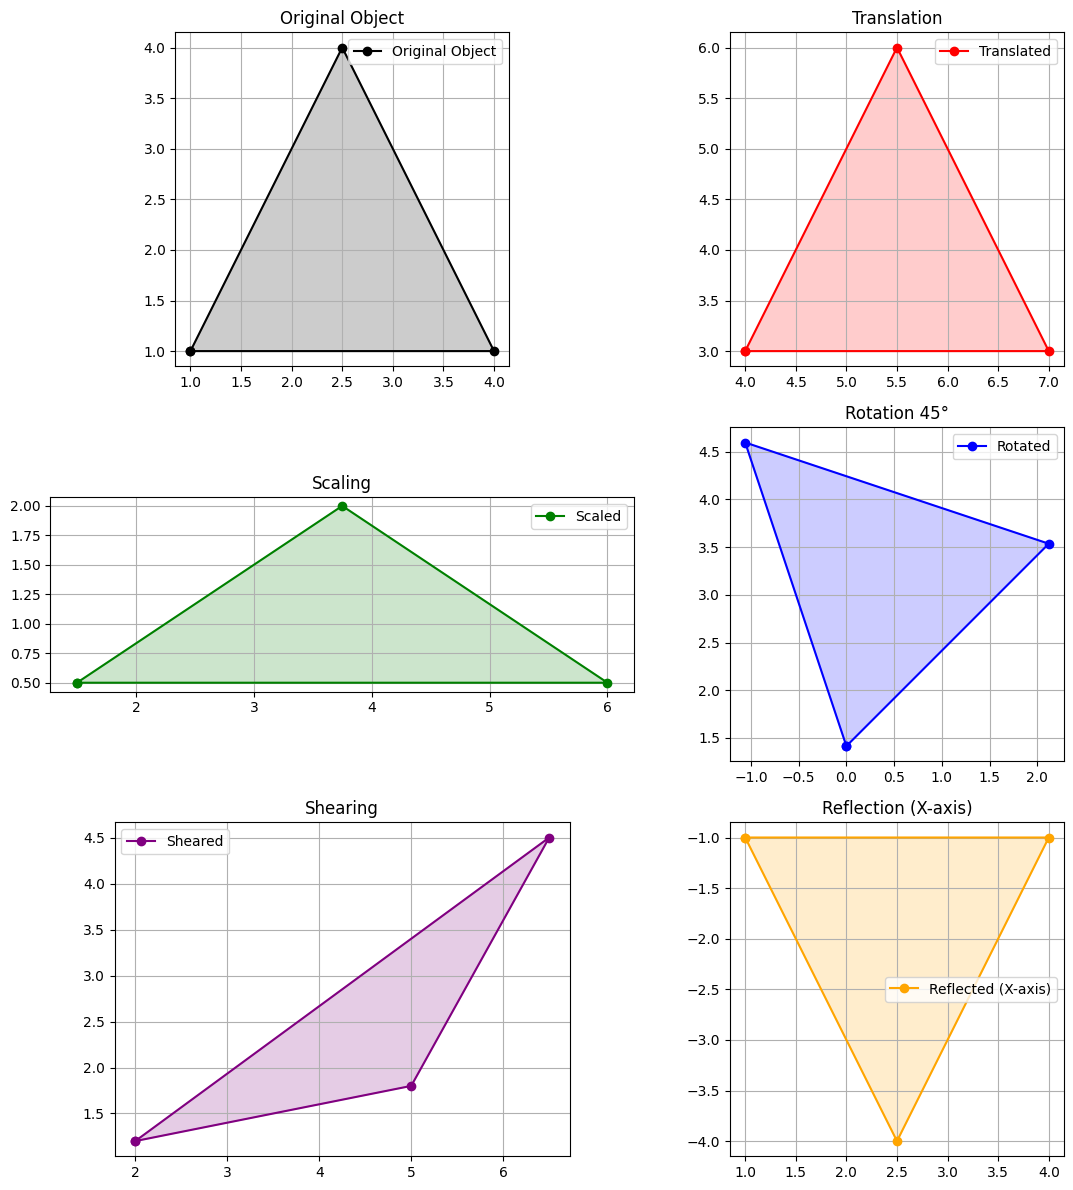

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def plot_shape(ax, points, label, color):
    x = points[:, 0]
    y = points[:, 1]

    ax.plot(x, y, color=color, marker="o", label=label)
    ax.fill(x, y, color=color, alpha=0.2)
    ax.set_aspect("equal")
    ax.grid(True)
    ax.legend()

def add_homogeneous(points):
    ones = np.ones((points.shape[0], 1))
    return np.hstack([points, ones])

def apply_transform(points, matrix):
    homogeneous = add_homogeneous(points)
    transformed = homogeneous @ matrix.T
    return transformed[:, :2]

def translation(tx, ty):
    return np.array([
        [1, 0, tx],
        [0, 1, ty],
        [0, 0, 1]
    ])

def scaling(sx, sy):
    return np.array([
        [sx, 0, 0],
        [0, sy, 0],
        [0, 0, 1]
    ])

def rotation(angle_deg):
    rad = np.radians(angle_deg)
    return np.array([
        [np.cos(rad), -np.sin(rad), 0],
        [np.sin(rad),  np.cos(rad), 0],
        [0, 0, 1]
    ])

def shearing(shx, shy):
    return np.array([
        [1, shx, 0],
        [shy, 1, 0],
        [0, 0, 1]
    ])

def reflection(axis):
    if axis == "x":
        return np.array([
            [1, 0, 0],
            [0, -1, 0],
            [0, 0, 1]
        ])
    elif axis == "y":
        return np.array([
            [-1, 0, 0],
            [0, 1, 0],
            [0, 0, 1]
        ])
    elif axis == "origin":
        return np.array([
            [-1, 0, 0],
            [0, -1, 0],
            [0, 0, 1]
        ])
    else:
        raise ValueError("Axis must be 'x', 'y', or 'origin'")

object_points = np.array([
    [1, 1],
    [4, 1],
    [2.5, 4],
    [1, 1]
])

translated = apply_transform(object_points, translation(3, 2))
scaled = apply_transform(object_points, scaling(1.5, 0.5))
rotated = apply_transform(object_points, rotation(45))
sheared = apply_transform(object_points, shearing(1, 0.2))
reflected = apply_transform(object_points, reflection("x"))

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

plot_shape(axes[0], object_points, "Original Object", "black")
axes[0].set_title("Original Object")

plot_shape(axes[1], translated, "Translated", "red")
axes[1].set_title("Translation")

plot_shape(axes[2], scaled, "Scaled", "green")
axes[2].set_title("Scaling")

plot_shape(axes[3], rotated, "Rotated", "blue")
axes[3].set_title("Rotation 45°")

plot_shape(axes[4], sheared, "Sheared", "purple")
axes[4].set_title("Shearing")

plot_shape(axes[5], reflected, "Reflected (X-axis)", "orange")
axes[5].set_title("Reflection (X-axis)")

plt.tight_layout()
plt.savefig("Exp6_Output.png")
plt.show()